# Sensor Contribution Experiment — Accelerometer vs Gyroscope vs Combined

**Project:** Human Activity Recognition Using Smartphone Sensor Data  
**Extended task:** Measure how much performance is lost when only accelerometer or only gyroscope signals are used.

This notebook trains the **same LSTM architecture** under three controlled input conditions:

1. **Accelerometer only** — body acceleration and total acceleration (6 channels)
2. **Gyroscope only** — body gyroscope (3 channels)
3. **Combined sensors** — all accelerometer and gyroscope channels (9 channels)

## Experimental design

The UCI HAR raw inertial windows contain 128 time steps and nine channels:

- `body_acc_x`, `body_acc_y`, `body_acc_z`
- `body_gyro_x`, `body_gyro_y`, `body_gyro_z`
- `total_acc_x`, `total_acc_y`, `total_acc_z`

The official UCI training and test partitions are used. Each channel is standardized using statistics calculated **only from the training set**. Performance is reported using accuracy, macro precision, macro recall, macro F1, per-class metrics, and confusion matrices.

In [4]:
# Imports and reproducibility
import os
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
# Configuration
# Set FAST_RUN=True only to verify that the notebook runs. Use False for final results.
FAST_RUN = False
EPOCHS = 5 if FAST_RUN else 60
BATCH_SIZE = 64
PATIENCE = 3 if FAST_RUN else 8

OUTPUT_DIR = Path('/kaggle/working/sensor_contribution_results') if Path('/kaggle/working').exists() else Path('sensor_contribution_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    'WALKING',
    'WALKING_UPSTAIRS',
    'WALKING_DOWNSTAIRS',
    'SITTING',
    'STANDING',
    'LAYING',
]

SIGNAL_NAMES = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z',
]

EXPERIMENTS = {
    'Accelerometer only': [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z',
    ],
    'Gyroscope only': [
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    ],
    'Combined sensors': SIGNAL_NAMES,
}

print('Results will be saved to:', OUTPUT_DIR.resolve())

Results will be saved to: /kaggle/working/sensor_contribution_results


## Locate the UCI HAR dataset

The code automatically searches common Kaggle and local locations. If automatic detection fails, set `UCI_ROOT` manually to the folder named `UCI HAR Dataset`.

In [6]:
def is_uci_root(path: Path) -> bool:
    required = [
        path / 'train' / 'Inertial Signals',
        path / 'test' / 'Inertial Signals',
        path / 'train' / 'y_train.txt',
        path / 'test' / 'y_test.txt',
    ]
    return all(p.exists() for p in required)

candidate_roots = [
    Path('/kaggle/input/datasets/asweerasinghe/uci-dataset/UCI HAR Dataset'),
    Path('/kaggle/input/uci-dataset/UCI HAR Dataset'),
    Path('/kaggle/input/uci-har-dataset/UCI HAR Dataset'),
    Path('/kaggle/input/human-activity-recognition-with-smartphones/UCI HAR Dataset'),
    Path('UCI HAR Dataset'),
    Path('../input/UCI HAR Dataset'),
]

UCI_ROOT = next((p for p in candidate_roots if is_uci_root(p)), None)

if UCI_ROOT is None and Path('/kaggle/input').exists():
    for p in Path('/kaggle/input').rglob('UCI HAR Dataset'):
        if is_uci_root(p):
            UCI_ROOT = p
            break

if UCI_ROOT is None:
    raise FileNotFoundError(
        'Could not locate the UCI HAR Dataset folder. '
        'Add the raw UCI HAR dataset to the Kaggle notebook, then set UCI_ROOT manually.'
    )

print('UCI dataset root:', UCI_ROOT)

UCI dataset root: /kaggle/input/datasets/asweerasinghe/dataset-har/UCI HAR Dataset


## Load raw time-series windows

Each signal file has one row per 128-step activity window. The nine files are stacked into a three-dimensional array:

`number of samples × 128 time steps × number of channels`

In [7]:
def load_signal(split: str, signal_name: str) -> np.ndarray:
    path = UCI_ROOT / split / 'Inertial Signals' / f'{signal_name}_{split}.txt'
    if not path.exists():
        raise FileNotFoundError(f'Missing signal file: {path}')
    return pd.read_csv(path, sep=r'\s+', header=None).to_numpy(dtype=np.float32)


def load_raw_split(split: str):
    signals = [load_signal(split, name) for name in SIGNAL_NAMES]
    X = np.stack(signals, axis=-1)  # samples, 128, 9

    y_path = UCI_ROOT / split / f'y_{split}.txt'
    subject_path = UCI_ROOT / split / f'subject_{split}.txt'

    y = pd.read_csv(y_path, sep=r'\s+', header=None).iloc[:, 0].to_numpy(dtype=np.int64) - 1
    subjects = pd.read_csv(subject_path, sep=r'\s+', header=None).iloc[:, 0].to_numpy(dtype=np.int64)
    return X, y, subjects


X_train_all, y_train, subject_train = load_raw_split('train')
X_test_all, y_test, subject_test = load_raw_split('test')

assert X_train_all.shape[1:] == (128, 9)
assert X_test_all.shape[1:] == (128, 9)
assert set(np.unique(y_train)) == set(range(6))
assert set(np.unique(y_test)) == set(range(6))

print('Raw training shape:', X_train_all.shape)
print('Raw test shape    :', X_test_all.shape)
print('Training subjects :', len(np.unique(subject_train)), np.unique(subject_train))
print('Test subjects     :', len(np.unique(subject_test)), np.unique(subject_test))
print('Class counts (train):')
print(pd.Series(y_train).map(dict(enumerate(CLASS_NAMES))).value_counts().reindex(CLASS_NAMES))

Raw training shape: (7352, 128, 9)
Raw test shape    : (2947, 128, 9)
Training subjects : 21 [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Test subjects     : 9 [ 2  4  9 10 12 13 18 20 24]
Class counts (train):
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
SITTING               1286
STANDING              1374
LAYING                1407
Name: count, dtype: int64


## Channel selection and leakage-safe normalization

For each experiment, the requested channels are selected first. Means and standard deviations are then learned from the training data and applied to both training and test data.

In [8]:
CHANNEL_INDEX = {name: i for i, name in enumerate(SIGNAL_NAMES)}


def select_channels(X: np.ndarray, channel_names: list[str]) -> np.ndarray:
    indices = [CHANNEL_INDEX[name] for name in channel_names]
    return X[:, :, indices].copy()


def standardize_windows(X_train: np.ndarray, X_test: np.ndarray):
    # One mean and standard deviation per sensor channel, learned from training only.
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)
    return (X_train - mean) / std, (X_test - mean) / std, mean, std


for experiment_name, channels in EXPERIMENTS.items():
    sample = select_channels(X_train_all, channels)
    print(f'{experiment_name:22s}: {sample.shape} | {len(channels)} channels')

Accelerometer only    : (7352, 128, 6) | 6 channels
Gyroscope only        : (7352, 128, 3) | 3 channels
Combined sensors      : (7352, 128, 9) | 9 channels


## Fixed LSTM architecture

This function is reused without modification in all three experiments. Only `input_shape[-1]`, which reflects the number of available sensor channels, changes.

In [9]:
def build_lstm_model(input_shape: tuple[int, int], num_classes: int = 6) -> tf.keras.Model:
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.30),
        LSTM(64),
        Dropout(0.30),
        Dense(128, activation='relu'),
        Dropout(0.30),
        Dense(num_classes, activation='softmax'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

# Display the architecture once using the combined input shape.
build_lstm_model((128, 9)).summary()

I0000 00:00:1785645236.677146      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785645236.679972      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,582 (908.52 KB)

 Trainable params: 232,582 (908.52 KB)

 Non-trainable params: 0 (0.00 B)

## Training and evaluation functions

Each experiment saves:

- best trained model
- training curves
- confusion matrix
- per-class classification report
- predictions
- summary metrics

In [10]:
def plot_training_history(history, experiment_slug: str):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 5))
    plt.plot(hist['loss'], label='Training loss')
    plt.plot(hist['val_loss'], label='Test loss')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical cross-entropy')
    plt.title(f'Loss — {experiment_slug}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{experiment_slug}_loss.png', dpi=200)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(hist['accuracy'], label='Training accuracy')
    plt.plot(hist['val_accuracy'], label='Test accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy — {experiment_slug}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{experiment_slug}_accuracy.png', dpi=200)
    plt.show()


def evaluate_predictions(y_true, y_pred, experiment_name: str, experiment_slug: str):
    metrics = {
        'Experiment': experiment_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(6)),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(OUTPUT_DIR / f'{experiment_slug}_classification_report.csv')

    cm = confusion_matrix(y_true, y_pred, labels=list(range(6)))
    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', values_format='d', xticks_rotation=35
    )
    ax.set_title(f'Confusion Matrix — {experiment_name}')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{experiment_slug}_confusion_matrix.png', dpi=200)
    plt.show()

    print(pd.Series(metrics).to_string())
    display(report_df.round(4))
    return metrics, report_df


def run_experiment(experiment_name: str, channels: list[str]):
    print('=' * 80)
    print('EXPERIMENT:', experiment_name)
    print('CHANNELS:', channels)
    print('=' * 80)

    tf.keras.backend.clear_session()
    gc.collect()
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    slug = experiment_name.lower().replace(' ', '_')
    X_train = select_channels(X_train_all, channels)
    X_test = select_channels(X_test_all, channels)
    X_train, X_test, channel_mean, channel_std = standardize_windows(X_train, X_test)

    if FAST_RUN:
        # Stratified small samples for a quick execution check only.
        rng = np.random.default_rng(SEED)
        train_idx = np.concatenate([
            rng.choice(np.where(y_train == c)[0], size=min(250, np.sum(y_train == c)), replace=False)
            for c in range(6)
        ])
        test_idx = np.concatenate([
            rng.choice(np.where(y_test == c)[0], size=min(100, np.sum(y_test == c)), replace=False)
            for c in range(6)
        ])
        rng.shuffle(train_idx)
        rng.shuffle(test_idx)
        X_train, y_train_used = X_train[train_idx], y_train[train_idx]
        X_test, y_test_used = X_test[test_idx], y_test[test_idx]
    else:
        y_train_used = y_train
        y_test_used = y_test

    y_train_cat = to_categorical(y_train_used, num_classes=6)
    y_test_cat = to_categorical(y_test_used, num_classes=6)

    model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
    model_path = OUTPUT_DIR / f'{slug}_best.keras'

    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=max(2, PATIENCE // 3), min_lr=1e-6, verbose=1
        ),
        ModelCheckpoint(
            model_path, monitor='val_loss',
            save_best_only=True, verbose=1
        ),
    ]

    history = model.fit(
        X_train,
        y_train_cat,
        validation_data=(X_test, y_test_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )

    probabilities = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    metrics, report_df = evaluate_predictions(
        y_test_used, predictions, experiment_name, slug
    )
    metrics['Channels'] = ', '.join(channels)
    metrics['Number of channels'] = len(channels)
    metrics['Epochs trained'] = len(history.history['loss'])

    prediction_df = pd.DataFrame({
        'Actual ID': y_test_used,
        'Actual Activity': [CLASS_NAMES[i] for i in y_test_used],
        'Predicted ID': predictions,
        'Predicted Activity': [CLASS_NAMES[i] for i in predictions],
    })
    prediction_df.to_csv(OUTPUT_DIR / f'{slug}_predictions.csv', index=False)

    np.savez(
        OUTPUT_DIR / f'{slug}_normalization.npz',
        mean=channel_mean,
        std=channel_std,
        channels=np.array(channels),
    )

    plot_training_history(history, slug)
    return metrics, report_df, history

## Run all three experiments

Full training can take a while, especially without a GPU. On Kaggle, enable a GPU accelerator before running this section.

EXPERIMENT: Accelerometer only
CHANNELS: ['body_acc_x', 'body_acc_y', 'body_acc_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']
Epoch 1/60
114/115 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5762 - loss: 1.0801
Epoch 1: val_loss improved from None to 0.46150, saving model to /kaggle/working/sensor_contribution_results/accelerometer_only_best.keras

Epoch 1: finished saving model to /kaggle/working/sensor_contribution_results/accelerometer_only_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7353 - loss: 0.7043 - val_accuracy: 0.8358 - val_loss: 0.4615 - learning_rate: 0.0010
Epoch 2/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8866 - loss: 0.3181
Epoch 2: val_loss improved from 0.46150 to 0.33989, saving model to /kaggle/working/sensor_contribution_results/accelerometer_only_best.keras

Epoch 2: finished saving model to /kaggle/working/sensor_contribution_results/accelerometer_only_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.

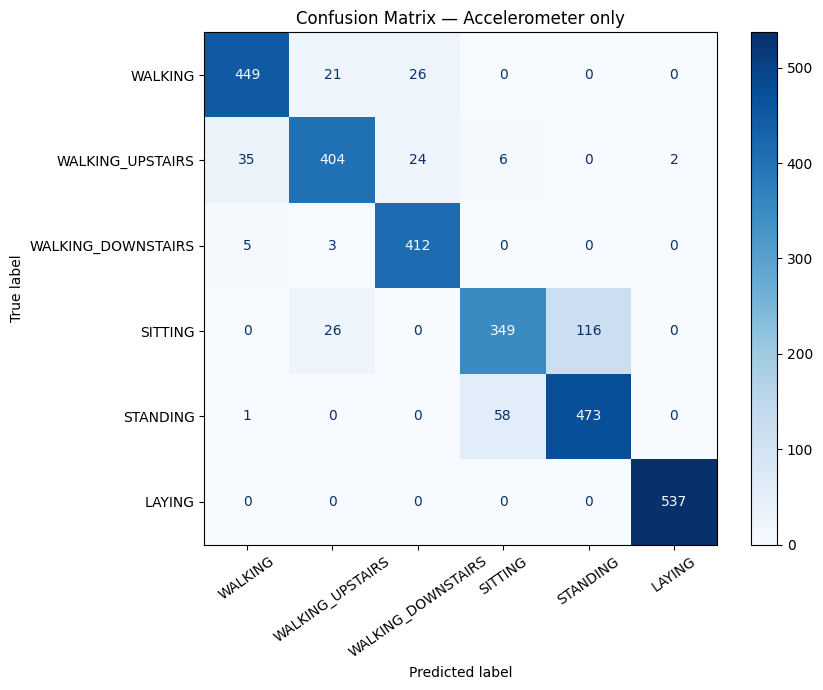

Experiment         Accelerometer only
Accuracy                     0.890397
Macro Precision              0.890392
Macro Recall                 0.890639
Macro F1                     0.888776
Weighted F1                  0.888905


,precision,recall,f1-score,support
WALKING,0.9163,0.9052,0.9108,496.0000
WALKING_UPSTAIRS,0.8899,0.8577,0.8735,471.0000
WALKING_DOWNSTAIRS,0.8918,0.9810,0.9342,420.0000
SITTING,0.8450,0.7108,0.7721,491.0000
STANDING,0.8031,0.8891,0.8439,532.0000
LAYING,0.9963,1.0000,0.9981,537.0000
accuracy,0.8904,0.8904,0.8904,0.8904
macro avg,0.8904,0.8906,0.8888,2947.0000
weighted avg,0.8908,0.8904,0.8889,2947.0000


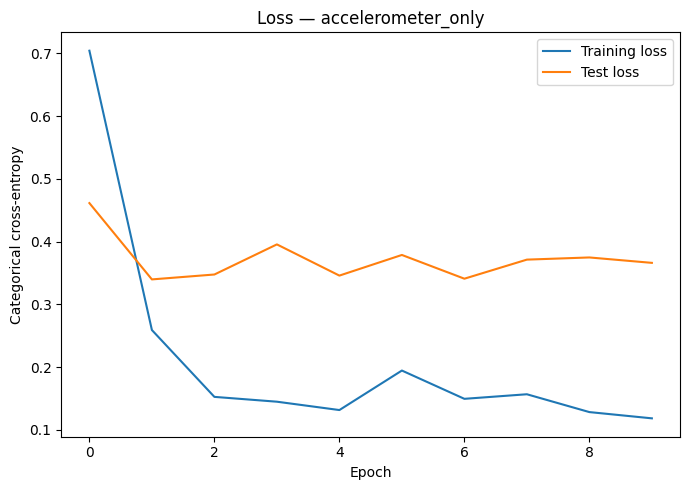

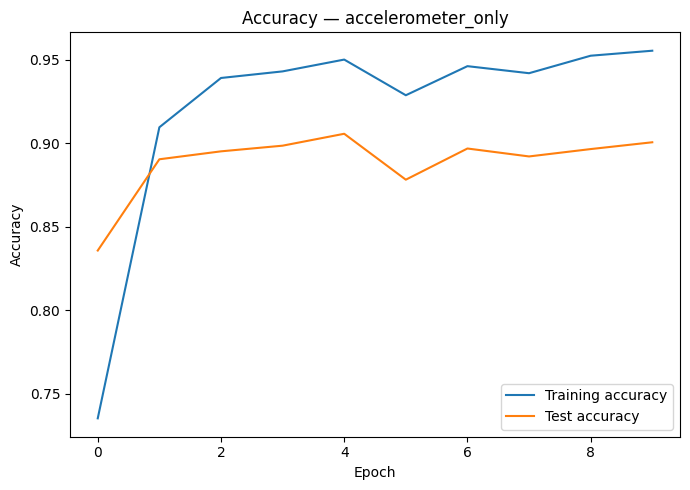

EXPERIMENT: Gyroscope only
CHANNELS: ['body_gyro_x', 'body_gyro_y', 'body_gyro_z']
Epoch 1/60
113/115 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3277 - loss: 1.4669
Epoch 1: val_loss improved from None to 0.90606, saving model to /kaggle/working/sensor_contribution_results/gyroscope_only_best.keras

Epoch 1: finished saving model to /kaggle/working/sensor_contribution_results/gyroscope_only_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.3945 - loss: 1.2332 - val_accuracy: 0.5501 - val_loss: 0.9061 - learning_rate: 0.0010
Epoch 2/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5482 - loss: 0.8828
Epoch 2: val_loss improved from 0.90606 to 0.82754, saving model to /kaggle/working/sensor_contribution_results/gyroscope_only_best.keras

Epoch 2: finished saving model to /kaggle/working/sensor_contribution_results/gyroscope_only_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.5495 - loss: 0.8697 - val_accuracy: 0.5752 - val_loss: 0.8275 

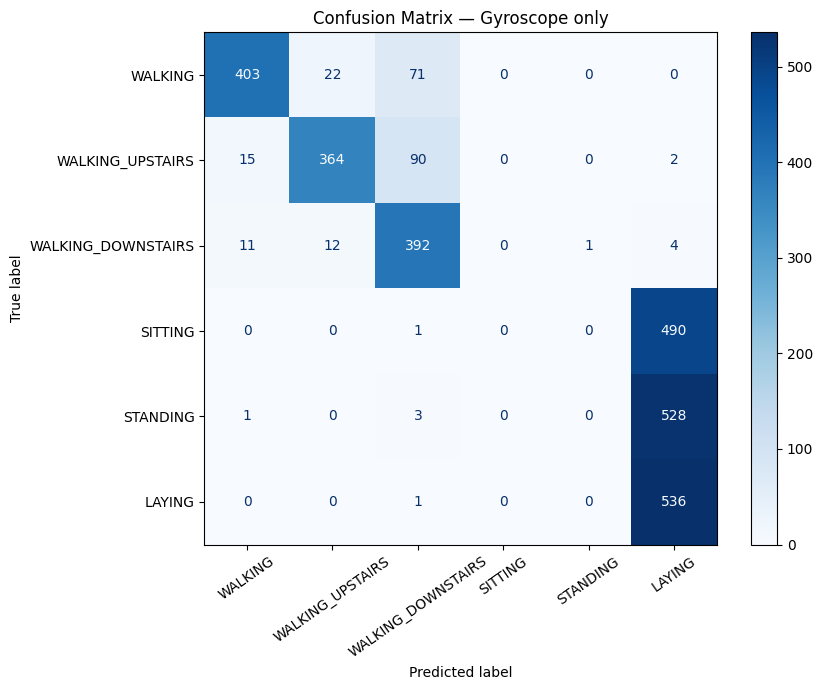

Experiment         Gyroscope only
Accuracy                 0.575161
Macro Precision           0.48298
Macro Recall             0.586132
Macro F1                   0.5035
Weighted F1              0.487786


,precision,recall,f1-score,support
WALKING,0.9372,0.8125,0.8704,496.0000
WALKING_UPSTAIRS,0.9146,0.7728,0.8377,471.0000
WALKING_DOWNSTAIRS,0.7025,0.9333,0.8016,420.0000
SITTING,0.0000,0.0000,0.0000,491.0000
STANDING,0.0000,0.0000,0.0000,532.0000
LAYING,0.3436,0.9981,0.5112,537.0000
accuracy,0.5752,0.5752,0.5752,0.5752
macro avg,0.4830,0.5861,0.5035,2947.0000
weighted avg,0.4666,0.5752,0.4878,2947.0000


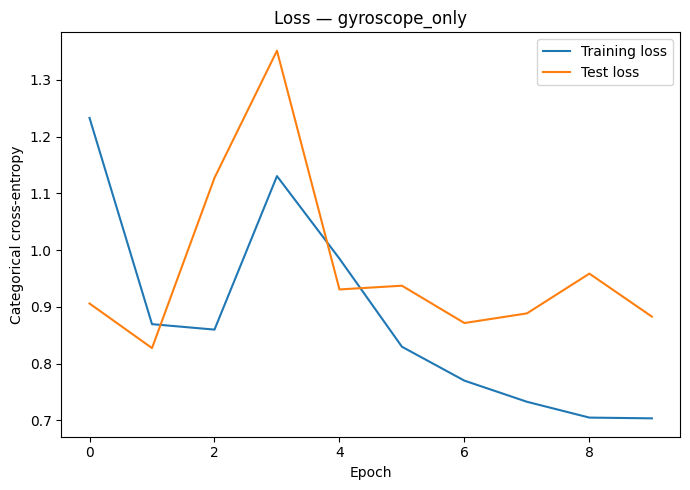

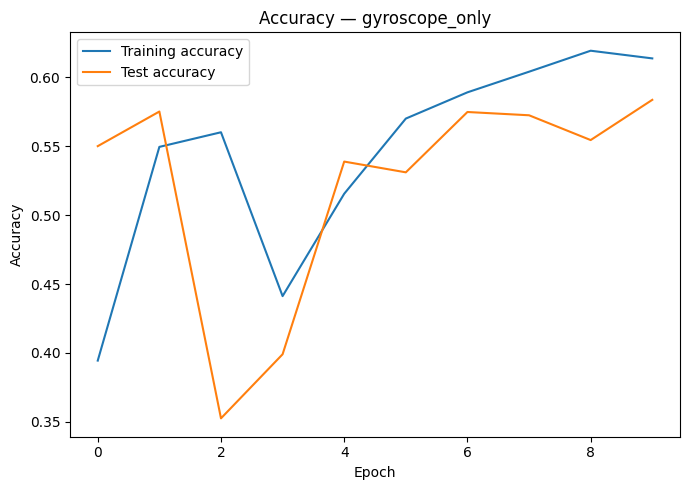

EXPERIMENT: Combined sensors
CHANNELS: ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']
Epoch 1/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6031 - loss: 1.0507
Epoch 1: val_loss improved from None to 0.34141, saving model to /kaggle/working/sensor_contribution_results/combined_sensors_best.keras

Epoch 1: finished saving model to /kaggle/working/sensor_contribution_results/combined_sensors_best.keras
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7580 - loss: 0.6596 - val_accuracy: 0.8958 - val_loss: 0.3414 - learning_rate: 0.0010
Epoch 2/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9271 - loss: 0.2065
Epoch 2: val_loss improved from 0.34141 to 0.28531, saving model to /kaggle/working/sensor_contribution_results/combined_sensors_best.keras

Epoch 2: finished saving model to /kaggle/working/sensor_contribution_results/combined_sensors_best.keras
115/115 ━━━━━━━━━━━━━

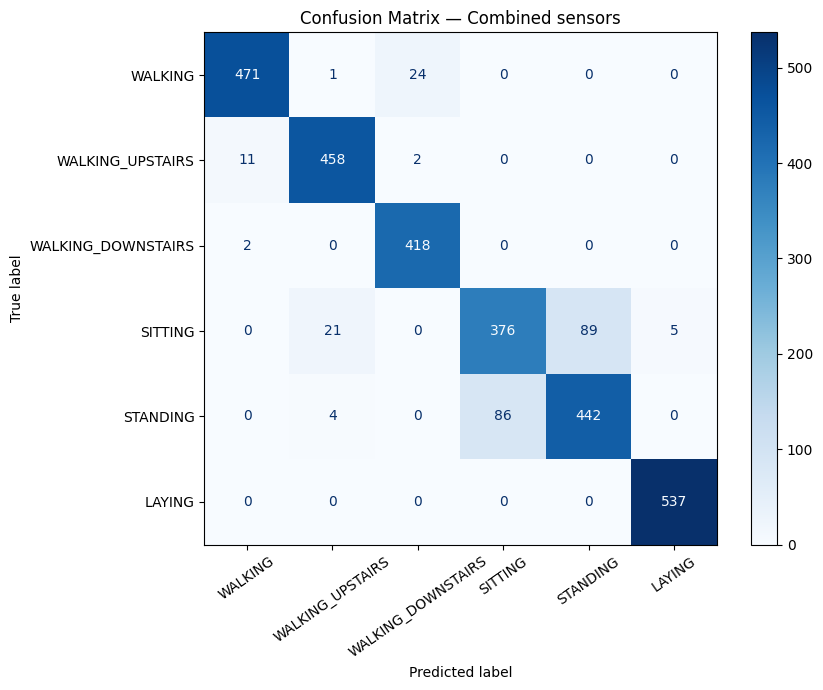

Experiment         Combined sensors
Accuracy                   0.916865
Macro Precision            0.916314
Macro Recall               0.918974
Macro F1                    0.91734
Weighted F1                0.915945


,precision,recall,f1-score,support
WALKING,0.9731,0.9496,0.9612,496.0000
WALKING_UPSTAIRS,0.9463,0.9724,0.9592,471.0000
WALKING_DOWNSTAIRS,0.9414,0.9952,0.9676,420.0000
SITTING,0.8139,0.7658,0.7891,491.0000
STANDING,0.8324,0.8308,0.8316,532.0000
LAYING,0.9908,1.0000,0.9954,537.0000
accuracy,0.9169,0.9169,0.9169,0.9169
macro avg,0.9163,0.9190,0.9173,2947.0000
weighted avg,0.9156,0.9169,0.9159,2947.0000


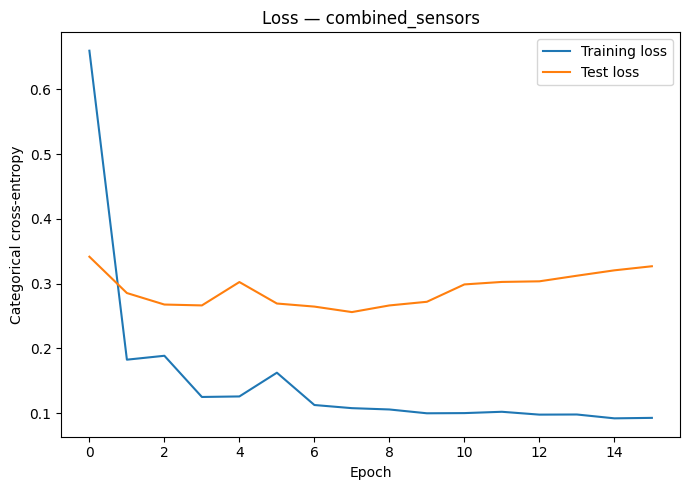

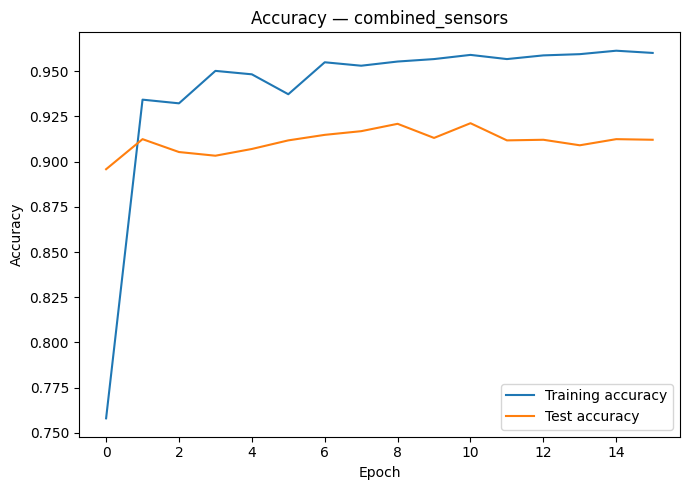

,Experiment,Number of channels,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Epochs trained
2,Combined sensors,9,0.91686,0.91631,0.91897,0.91734,0.91595,16
0,Accelerometer only,6,0.89040,0.89039,0.89064,0.88878,0.88890,10
1,Gyroscope only,3,0.57516,0.48298,0.58613,0.50350,0.48779,10


In [11]:
all_metrics = []
all_reports = {}
all_histories = {}

for experiment_name, channels in EXPERIMENTS.items():
    metrics, report_df, history = run_experiment(experiment_name, channels)
    all_metrics.append(metrics)
    all_reports[experiment_name] = report_df
    all_histories[experiment_name] = history.history

results_df = pd.DataFrame(all_metrics)
results_df.to_csv(OUTPUT_DIR / 'sensor_experiment_summary.csv', index=False)

display(
    results_df[
        ['Experiment', 'Number of channels', 'Accuracy',
         'Macro Precision', 'Macro Recall', 'Macro F1', 'Weighted F1', 'Epochs trained']
    ].sort_values('Macro F1', ascending=False).round(5)
)

## Compare performance loss against the combined model

A positive value means that using only one sensor type reduced Macro F1 relative to the combined-sensor model.

,Experiment,Number of channels,Accuracy,Macro F1,Macro F1 loss vs combined,Relative F1 loss (%)
0,Combined sensors,9,0.91686,0.91734,0.00000,0.00000
1,Accelerometer only,6,0.89040,0.88878,0.02856,3.11375
2,Gyroscope only,3,0.57516,0.50350,0.41384,45.11310


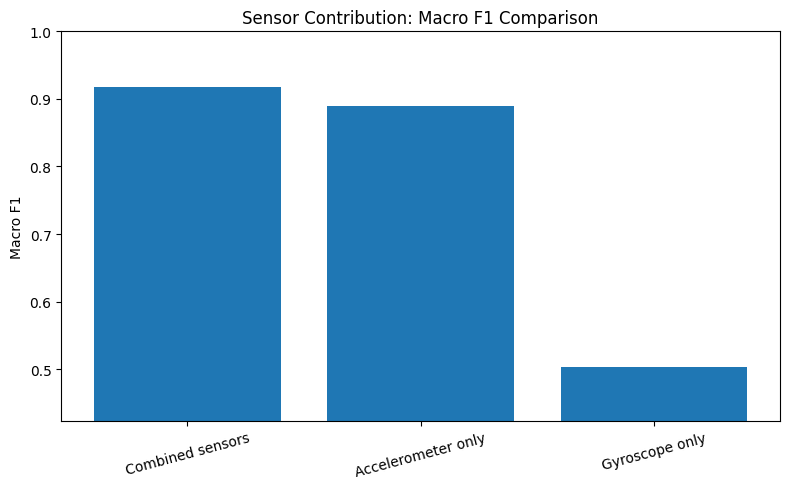

In [12]:
comparison_df = results_df[
    ['Experiment', 'Number of channels', 'Accuracy', 'Macro F1']
].copy()

combined_f1 = comparison_df.loc[
    comparison_df['Experiment'] == 'Combined sensors', 'Macro F1'
].iloc[0]

comparison_df['Macro F1 loss vs combined'] = combined_f1 - comparison_df['Macro F1']
comparison_df['Relative F1 loss (%)'] = (
    comparison_df['Macro F1 loss vs combined'] / combined_f1 * 100
)
comparison_df = comparison_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)
comparison_df.to_csv(OUTPUT_DIR / 'sensor_contribution_comparison.csv', index=False)

display(comparison_df.round(5))

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Experiment'], comparison_df['Macro F1'])
plt.ylabel('Macro F1')
plt.title('Sensor Contribution: Macro F1 Comparison')
plt.ylim(max(0, comparison_df['Macro F1'].min() - 0.08), 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'macro_f1_comparison.png', dpi=200)
plt.show()

## Per-class F1 comparison

This comparison shows which activities benefit most from combining accelerometer and gyroscope signals.

,Accelerometer only,Gyroscope only,Combined sensors
Activity,,,
WALKING,0.9108,0.8704,0.9612
WALKING_UPSTAIRS,0.8735,0.8377,0.9592
WALKING_DOWNSTAIRS,0.9342,0.8016,0.9676
SITTING,0.7721,0.0000,0.7891
STANDING,0.8439,0.0000,0.8316
LAYING,0.9981,0.5112,0.9954


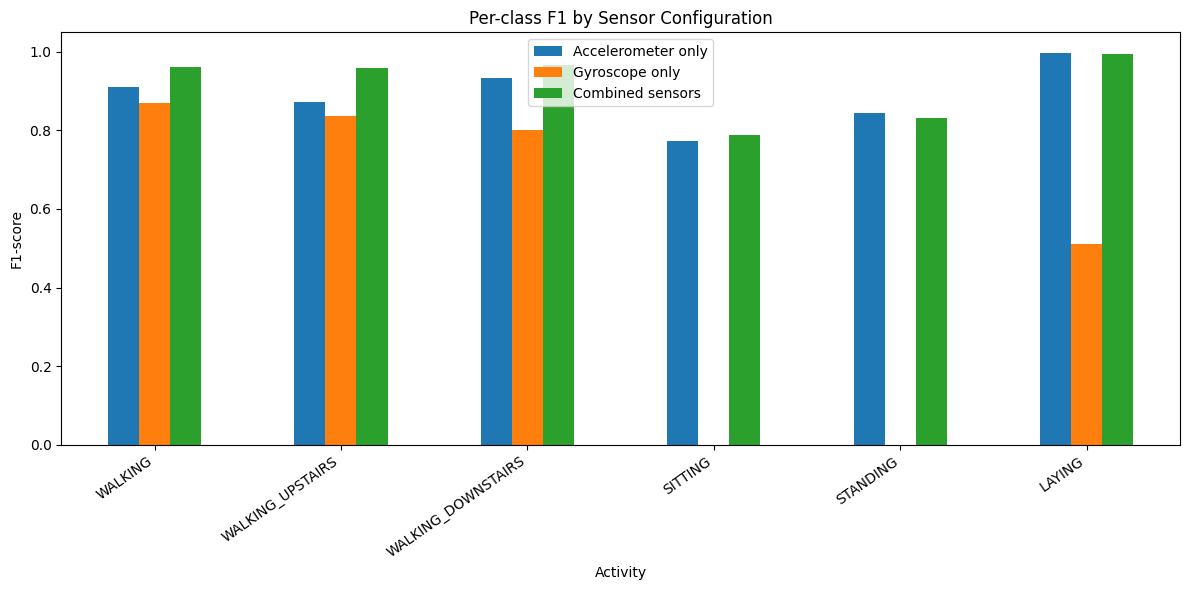

In [13]:
per_class_f1 = pd.DataFrame(index=CLASS_NAMES)
for experiment_name, report_df in all_reports.items():
    per_class_f1[experiment_name] = report_df.loc[CLASS_NAMES, 'f1-score']

per_class_f1.index.name = 'Activity'
per_class_f1.to_csv(OUTPUT_DIR / 'per_class_f1_comparison.csv')
display(per_class_f1.round(4))

ax = per_class_f1.plot(kind='bar', figsize=(12, 6))
ax.set_ylabel('F1-score')
ax.set_title('Per-class F1 by Sensor Configuration')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_f1_comparison.png', dpi=200)
plt.show()

## Automatically generated interpretation

Use this as a starting point for the report. Confirm the wording against the displayed results before submitting it.

In [14]:
summary = comparison_df.set_index('Experiment')
acc_f1 = summary.loc['Accelerometer only', 'Macro F1']
gyro_f1 = summary.loc['Gyroscope only', 'Macro F1']
combined_f1 = summary.loc['Combined sensors', 'Macro F1']

acc_loss = combined_f1 - acc_f1
gyro_loss = combined_f1 - gyro_f1
best_name = summary['Macro F1'].idxmax()

interpretation = (
    'The same LSTM architecture was evaluated with accelerometer-only, '
    'gyroscope-only, and combined sensor inputs.\n\n'
    f'The accelerometer-only model achieved a Macro F1 of {acc_f1:.4f}, '
    f'while the gyroscope-only model achieved {gyro_f1:.4f}. '
    f'The combined-sensor model achieved {combined_f1:.4f}. '
    f'Relative to the combined model, removing gyroscope information changed '
    f'Macro F1 by {acc_loss:+.4f}, and removing accelerometer information '
    f'changed it by {gyro_loss:+.4f}.\n\n'
    f'The highest Macro F1 was obtained by: {best_name}.\n\n'
    'If the combined model is clearly better than both single-sensor models, '
    'this supports the conclusion that accelerometer and gyroscope signals '
    'provide complementary information. If a single-sensor model performs '
    'similarly or better, the result suggests that the additional sensor may '
    'offer limited benefit under this architecture and evaluation setting. '
    'Per-class F1 scores should be used to identify activities for which each '
    'sensor is most valuable.\n'
)

print(interpretation)
(OUTPUT_DIR / 'automatic_interpretation.txt').write_text(interpretation, encoding='utf-8')

The same LSTM architecture was evaluated with accelerometer-only, gyroscope-only, and combined sensor inputs.

The accelerometer-only model achieved a Macro F1 of 0.8888, while the gyroscope-only model achieved 0.5035. The combined-sensor model achieved 0.9173. Relative to the combined model, removing gyroscope information changed Macro F1 by +0.0286, and removing accelerometer information changed it by +0.4138.

The highest Macro F1 was obtained by: Combined sensors.

If the combined model is clearly better than both single-sensor models, this supports the conclusion that accelerometer and gyroscope signals provide complementary information. If a single-sensor model performs similarly or better, the result suggests that the additional sensor may offer limited benefit under this architecture and evaluation setting. Per-class F1 scores should be used to identify activities for which each sensor is most valuable.



925

## Final files

The next cell lists every generated result. Download the CSV files, figures, and models from the notebook output directory after execution.

In [15]:
print('Generated files:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print('-', path.name)

Generated files:
- accelerometer_only_accuracy.png
- accelerometer_only_best.keras
- accelerometer_only_classification_report.csv
- accelerometer_only_confusion_matrix.png
- accelerometer_only_loss.png
- accelerometer_only_normalization.npz
- accelerometer_only_predictions.csv
- automatic_interpretation.txt
- combined_sensors_accuracy.png
- combined_sensors_best.keras
- combined_sensors_classification_report.csv
- combined_sensors_confusion_matrix.png
- combined_sensors_loss.png
- combined_sensors_normalization.npz
- combined_sensors_predictions.csv
- gyroscope_only_accuracy.png
- gyroscope_only_best.keras
- gyroscope_only_classification_report.csv
- gyroscope_only_confusion_matrix.png
- gyroscope_only_loss.png
- gyroscope_only_normalization.npz
- gyroscope_only_predictions.csv
- macro_f1_comparison.png
- per_class_f1_comparison.csv
- per_class_f1_comparison.png
- sensor_contribution_comparison.csv
- sensor_experiment_summary.csv


In [16]:
import shutil
import os

output_folder = "/kaggle/working/sensor_contribution_results"
zip_path = "/kaggle/working/sensor_contribution_results"

shutil.make_archive(
    zip_path,
    "zip",
    output_folder
)

print("Created:", zip_path + ".zip")
print("Size:", os.path.getsize(zip_path + ".zip") / (1024**2), "MB")

Created: /kaggle/working/sensor_contribution_results.zip
Size: 8.272566795349121 MB
